![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [3]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [4]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [5]:
# Celda 1
def mse(y):
    if y.shape[0] == 0:
        return 0
    return np.mean((y - y.mean())**2)

In [6]:
def reduccion_MSE(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    n = n_l + n_r
    
    if n_l == 0 or n_r == 0:
        return 0
    
    mse_parent = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    reduccion = mse_parent - (
        (n_l / n) * mse_l + (n_r / n) * mse_r
    )
    
    return reduccion

In [7]:
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    best_split = [0, 0, -np.inf]  # j, split, gain
    
    for j in features:
        col = X.iloc[:, j]
        
        # Si variable booleana
        if col.dtype == 'bool':
            
            # probamos un único split lógico
            split = True
            
            gain = reduccion_MSE(col.astype(int), y, 0.5)
            
            if gain > best_split[2]:
                best_split = [j, 0.5, gain]
        
        # Si variable numérica
        else:
            splits = np.percentile(
                col,
                np.arange(0, 100, 100.0 / (num_pct+1)).tolist()
            )
            splits = np.unique(splits)[1:]
            
            for split in splits:
                gain = reduccion_MSE(col, y, split)
                
                if gain > best_split[2]:
                    best_split = [j, split, gain]
    
    return best_split

In [8]:
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Caso base: una sola observación
    if X.shape[0] == 1:
        return dict(
            y_pred=y.iloc[0],
            level=level,
            split=-1,
            n_samples=1,
            gain=0
        )
    
    # Mejor split
    j, split, gain = best_split(X, y, num_pct)
    
    # Predicción del nodo = sólo se usa el promedio
    y_pred = y.mean()
    
    tree = dict(
        y_pred=y_pred,
        level=level,
        split=-1,
        n_samples=X.shape[0],
        gain=gain
    )
    
    # Criterios de parada
    if gain < min_gain:
        return tree
    
    if max_depth is not None and level >= max_depth:
        return tree
    
    # Partición
    col = X.iloc[:, j]

    if col.dtype == bool:
        filter_l = col == False
    else:
        filter_l = col < split
    
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    
    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree
    
    tree['split'] = [j, split]
    
    # Recursión
    tree['sl'] = tree_grow(
        X_l, y_l, level + 1,
        min_gain=min_gain,
        max_depth=max_depth,
        num_pct=num_pct
    )
    
    tree['sr'] = tree_grow(
        X_r, y_r, level + 1,
        min_gain=min_gain,
        max_depth=max_depth,
        num_pct=num_pct
    )
    
    return tree

In [9]:
tree1 = tree_grow(X_train, y_train, max_depth=5)

In [10]:
def predict_tree(tree, x):
    
    if tree['split'] == -1:
        return tree['y_pred']
    
    j, split = tree['split']
    
    if x[j] < split:
        return predict_tree(tree['sl'], x)
    else:
        return predict_tree(tree['sr'], x)

In [11]:
#predicciones:
y_pred_manual = X_test.apply(lambda row: predict_tree(tree1, row.values),axis=1)

In [12]:
mae = mean_absolute_error(y_test , y_pred_manual)
rmse = np.sqrt(np.mean((y_test - y_pred_manual)**2))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1267.673425053242
RMSE: 1698.580766106339


In [13]:
errormae = []
errorrmse = []
trees = {}

for i in range(1, 10):
    
    # entrenar árbol
    trees[i] = tree_grow(X_train, y_train, max_depth=i)
    
    # predecir
    y_pred_manual = X_test.apply(
        lambda row: predict_tree(trees[i], row.values),
        axis=1
    )
    
    # asegurar alineación
    y_pred_manual = y_pred_manual.reset_index(drop=True)
    y_test_fixed = y_test.reset_index(drop=True)
    
    # calcular métricas
    mae = mean_absolute_error(y_test_fixed, y_pred_manual)
    rmse = np.sqrt(np.mean((y_test_fixed - y_pred_manual)**2))
    
    # guardar resultados
    errormae.append(mae)
    errorrmse.append(rmse)

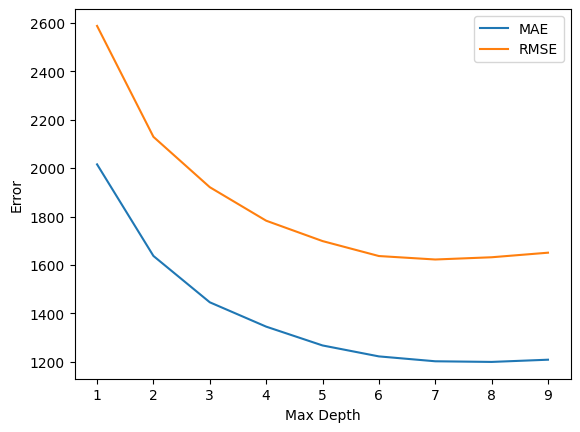

In [14]:
import matplotlib.pyplot as plt

plt.plot(range(1,10), errormae, label="MAE")
plt.plot(range(1,10), errorrmse, label="RMSE")
plt.xlabel("Max Depth")
plt.ylabel("Error")
plt.legend()
plt.show()

El punto de inflexión se observa alrededor de la profundida máxima de 5, sin emgargo se evidencia que el RMSE es 33% mayor que el MAE, por lo que puede haber outliers que estén afectando esta métrica.


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [15]:
# Celda 2
# Se crea un arreglo de 1 a 20
np.random.seed(1)

# Impresión de arreglo y muestreo aleatorio
nums = np.arange(1, 21)
print('Arreglo:', nums)
print('Muestreo aleatorio: ', np.random.choice(a=nums, size=20, replace=True))

Arreglo: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Muestreo aleatorio:  [ 6 12 13  9 10 12  6 16  1 17  2 13  8 14  7 19  6 19 12 11]


In [16]:
# Creación de 10 muestras de bootstrap 
np.random.seed(123)

n_samples = X_train.shape[0]
n_B = 10

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_B +1 )]
samples

[array([3582, 3454, 1346, ...,  826,  801, 5657],
       shape=(7031,), dtype=int32),
 array([6962, 3408, 2553, ..., 6611,  877, 6412],
       shape=(7031,), dtype=int32),
 array([1917, 3131,  384, ..., 2876, 6449, 6557],
       shape=(7031,), dtype=int32),
 array([3849, 4565, 6820, ..., 6835, 4643,  639],
       shape=(7031,), dtype=int32),
 array([2468, 3608, 1367, ..., 3108, 2961, 4357],
       shape=(7031,), dtype=int32),
 array([3142, 1537, 5966, ..., 3224, 6922, 3396],
       shape=(7031,), dtype=int32),
 array([6588, 3753, 1786, ..., 2131, 4627, 5672],
       shape=(7031,), dtype=int32),
 array([1289, 3776,  981, ..., 1891, 6034, 6165],
       shape=(7031,), dtype=int32),
 array([6079, 3819, 6976, ..., 6478, 2225, 5072],
       shape=(7031,), dtype=int32),
 array([3952, 3276,  896, ..., 4589, 1964,  893],
       shape=(7031,), dtype=int32)]

In [17]:
# Construcción un árbol de decisión para cada muestra boostrap

# Definición del modelo usando DecisionTreeRegressor de sklearn
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# DataFrame para guardar las predicciones de cada árbol
y_pred = pd.DataFrame(index=X_test.index, columns=[list(range(n_B))])

# Entrenamiento de un árbol sobre cada muestra boostrap y predicción sobre los datos de test
for i, sample in enumerate(samples):
    X_bag = X_train.iloc[sample]
    y_bag = y_train.iloc[sample]

    treereg.fit(X_bag, y_bag)
    
    y_pred.iloc[:,i] = treereg.predict(X_test)
    
y_pred

,0,1,2,3,4,5,6,7,8,9
257343,14980.0,13993.0,13649.0,13649.0,11788.0,13649.0,13993.0,13990.0,13990.0,13993.0
326011,6492.0,5995.0,5995.0,6987.0,5995.0,5995.0,5995.0,6987.0,5995.0,5995.0
242354,16491.0,16995.0,16491.0,15997.0,15997.0,16491.0,17591.0,16995.0,17404.0,16491.0
266376,21990.0,21990.0,22500.0,21990.0,15900.0,21990.0,22500.0,21990.0,15813.0,21990.0
396954,15988.0,16951.0,15988.0,15988.0,15988.0,17900.0,16951.0,16951.0,15988.0,15988.0
...,...,...,...,...,...,...,...,...,...,...
144298,13836.0,14800.0,14800.0,14800.0,14800.0,14681.0,14800.0,14800.0,13836.0,13836.0
364521,15999.0,14995.0,15999.0,16900.0,15999.0,15999.0,17300.0,15999.0,16900.0,15000.0
120072,23533.0,23533.0,20000.0,17700.0,17700.0,23533.0,17700.0,23533.0,23533.0,20000.0
99878,12989.0,12995.0,12989.0,12995.0,12991.0,12991.0,10995.0,12991.0,12991.0,12893.0


In [18]:
# Desempeño de cada árbol
for i in range(n_B):
    print('Árbol ', i, 'tiene un error: ', np.sqrt(mean_squared_error(y_pred.iloc[:,i], y_test)))

Árbol  0 tiene un error:  2141.613353645869
Árbol  1 tiene un error:  2136.3519863123465
Árbol  2 tiene un error:  2122.718759132052
Árbol  3 tiene un error:  2087.278992468617
Árbol  4 tiene un error:  2168.518742842026
Árbol  5 tiene un error:  2113.8811455834793
Árbol  6 tiene un error:  2127.933470769012
Árbol  7 tiene un error:  2184.414847251443
Árbol  8 tiene un error:  2138.1071697514985
Árbol  9 tiene un error:  2132.097520859104


In [19]:
# Predicciones promedio para cada obserbación del set de test
y_pred_bagging = y_pred.mean(axis=1)
# Errores al promediar las predicciones de todos los árboles
mae_final = mean_absolute_error(y_test, y_pred_bagging)
print("MAE Bagging:", mae_final)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
print("RMSE Bagging:", rmse_final)



MAE Bagging: 1340.0160739030025
RMSE Bagging: 1796.4355868399332


En este caso se observa nuevamente la diferencia del 33% entre el MAE y RMSE, valdría la pena revisar cuál es el peso de los outliers en los datos y las razones que lo causas, se observa un mejor desempeño del modelo ensayado en el punto anterior.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [27]:
# Celda 3
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_absolute_error

In [24]:
bagreg = BaggingRegressor(estimator=DecisionTreeRegressor(max_features="log2"), n_estimators=10, 
                          bootstrap=True, oob_score=True, random_state=1)

In [25]:
bagreg.fit(X_train, y_train)
y_pred = bagreg.predict(X_test)
y_pred

array([13011.8,  6612.8, 16692.6, ..., 22596.4, 12990.6, 11969.1],
      shape=(3464,))

In [30]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print('MSE: ', rmse)
print('MAE: ', mae)

MSE:  1824.7000069648657
MAE:  1361.8777493561897


Comentarios del desempeño del modelo
- el cambiar n_estimators = 10, y tener 10 árboles de regresión, adicionalmente max_features = log2 podría esto aumentar la varianza, se puede presentar mayor aletoriedad de variables y disminuir la precisión.
- En cuanto al resultado de análisis de error vemos en MSE = USD 1824.7 y MAE = USD 1361.9, podemos notar que son valores mas alto, lo cual, es peor desempeño que el de bagging manual e
- Igualmente se observa que hay una diferencia del 33%, 34% entre el MAE y RMSE, por ende, aunque no hay una diferencia grande entre las 2 medidas de error puede reflejar un resultado de predicción estable sin embargo es importante validar el peso de los outliers en los datos.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [53]:
# Celda 4
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Definición de modelo Random Forest para un problema de clasificación
clf = RandomForestRegressor()
clf

pd.Series(cross_val_score(clf, X_train, y_train, cv=10)).describe()

count    10.000000
mean      0.800776
std       0.023655
min       0.763202
25%       0.788871
50%       0.799815
75%       0.821243
max       0.831704
dtype: float64

In [54]:
scores = cross_val_score(
    clf,
    X_train,
    y_train,
    cv=10,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores)
rmse_rf_no_calibrado = rmse_scores.mean()

pd.Series(rmse_scores).describe()

count      10.000000
mean     1743.013597
std        74.481503
min      1631.312705
25%      1687.571705
50%      1737.440567
75%      1812.690402
max      1836.272363
dtype: float64

Al estructurar un modelo de **Random Forest sin calibración**, se observa un **error medio (RMSE) de USD 1,743** en el cálculo del valor de los vehículos, dadas las variables definidas. Esto indica que, en promedio, las predicciones del modelo se desvían en aproximadamente ese valor respecto al precio real.

Adicionalmente, se evidencia que el error oscila en un rango aproximado entre **USD 1,631 y USD 1,836**, lo cual sugiere una baja variabilidad en el desempeño del modelo y, por tanto, una buena estabilidad en sus predicciones.

Apriori, el modelo parece tener un buen desempeño incluso sin realizar calibración de los hiperparametros, sin embargo, es relevante realizar este procedimiento con el fin de validar si hay mejoras en la capacidad predictiva del modelo

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

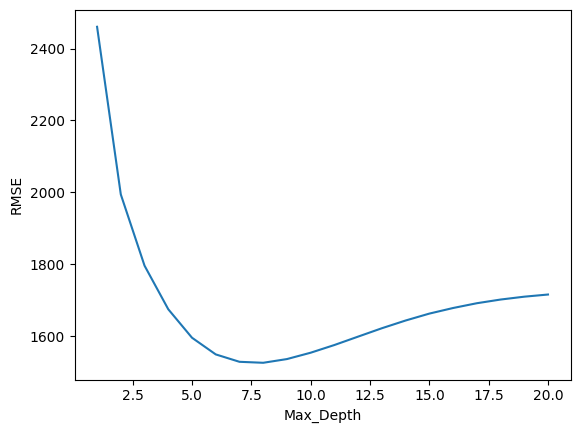

In [55]:
#MaxDepth

max_depth_range = range(1, 21)
MSE_Score_MaxDepth = []


for depth in max_depth_range:
    clf = RandomForestRegressor(n_estimators=200,max_depth=depth, random_state=1, n_jobs=-1)
    MSE_Score_MaxDepth.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

RMSE_scores_MaxDepth = [-score for score in MSE_Score_MaxDepth]

plt.plot(max_depth_range, RMSE_scores_MaxDepth)
plt.xlabel('Max_Depth')
plt.ylabel('RMSE')
plt.show()

Podemos evidenciar que la calibración de la profundidad maxima de los arboles (`max_depth`) tiene un impacto relevante en el desempeño del modelo. A medida que aumentamos la profundidad, el RSME disminuye considerablemente, alcanzando su valor minimo en una profundidad comprendida entre 7 y 8. 


A partir de este punto el error nuevamente empieza a incrementar, lo que sugiere la presencia de overfitting.

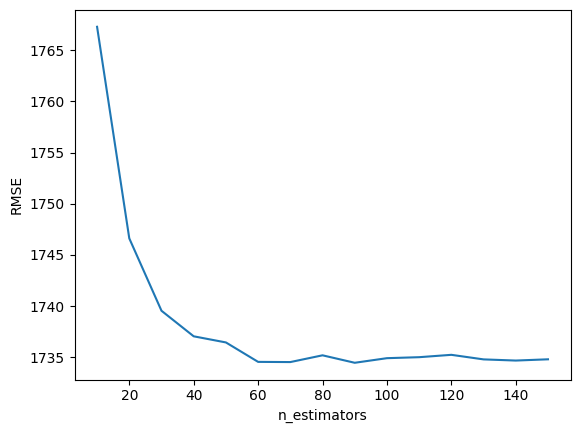

In [56]:
#estimators

estimator_range = range(10, 160, 10)
MSE_Score_Estimator = []


for estimator in estimator_range:
    clf = RandomForestRegressor(n_estimators=estimator, random_state=1, n_jobs=-1)
    MSE_Score_Estimator.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

RMSE_scores_Estimator = [-score for score in MSE_Score_Estimator]

plt.plot(estimator_range, RMSE_scores_Estimator)
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.show()

Podemos observar que la calibración del numero de estimadores (`n_estimators`), es decir, la cantidad de abroles que compone el bosque, tambien tiene bondades en la reducción del RSME.

Puntualmente, a medida que incrementamos la densidad del bosque, el error disminuye de forma significativa en las primeras iteraciones. Sin embargo, encontramos que el error alcanza su valor minimo a partir de los 60 arboles.

A partir de este punto se percibe que un incremento en la cantidad de arboles no representa mejoras representativas en el desempeño del modelo, ocasionado que en algunas cantidades especificas el error aumente ligeramente.

Por tanto, eligiremos los 60 arboles con el fin de no aumentar la complejidad del modelo ni dificultar la implementación del mismo.

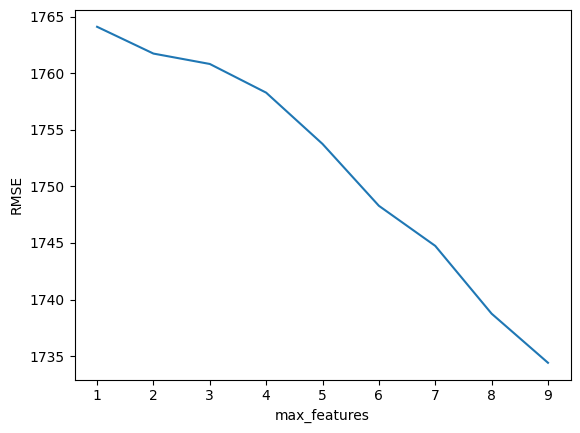

In [34]:
#maxfeatures

feature_range = range(1, X_train.shape[1] + 1)
MSE_scores_MaxFeatures = []

for feature in feature_range:
    clf = RandomForestRegressor(n_estimators=200, max_features=feature, random_state=1, n_jobs=-1)
    MSE_scores_MaxFeatures.append(cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

RMSE_scores_MaxFeatures = [-score for score in MSE_scores_MaxFeatures]

plt.plot(feature_range, RMSE_scores_MaxFeatures)
plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.show()

En cuanto al número maximo de variables contempladas en cada bifurcación (`max_features`), se observa una relación inversamente proporcional entre el error y el numero de variables utilizadas.

Es decir, a medida que se incrementa el número de variables tomadas en cuenta, el error disminuye continuamente, alcanzando su valor mínimo cuando se utiliza el 100% de las variables disponibles.

Con este comportamiento podemos inferir que no hay un valor significativo de información redundante en las variables, y que todas aportan información nueva que ayuda a mejorar el desempeño del modelo. Recomendamos hacer uso de todas las variables para obtener el mejor desempeño del modelo.

In [57]:
# Definición del modelo con los parámetros max_features=None y n_estimators=60
from sklearn.metrics import mean_squared_error


clf = RandomForestRegressor(n_estimators=60, max_features=None,max_depth=7, random_state=1, n_jobs=-1)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [58]:
y_pred = clf.predict(X_test)

rmse_rf_calibrado = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse_rf_calibrado)

1567.8405662314494


Ajustando el modelo haciendo uso de los parametros optimos obtenidos mediante las iteraciones anteriormente descritas y evaluandolo sobre la muestra de test, vemos que el RSME es de USD $1.567.84.

Este resultado representa una mejora de aproximadamente el 10.05% en el desempeño del modelo en contraste contra su versión sin calibración, demostrando el impacto positivo que tiene el proceso de optimización de los hiperparametros.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [33]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [62]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
#se implementa modelo con parametros estandar (n_estimators=100, learning_rate=0.1, max_depth=6 ... )
mxgb = XGBRegressor(random_state=1)
mxgb.fit(X_train, y_train)
y_pred = mxgb.predict(X_test)
rmse_xgb_no_calibrado = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE XGBoost:", rmse_xgb_no_calibrado)
print("Error Relativo:", rmse_xgb_no_calibrado/np.mean(y_test))

RMSE XGBoost: 1605.2354967418332
Error Relativo: 0.10994789111916249


In [60]:
np.mean(y_test)

np.float64(14599.966224018475)

Ejecutando el modelo XGBoost con parametros por defecto, en los cuales por lo general usa todos los datos y variables, asi como permitir muchos splits. se visualiza menor rendimiento comparado con el modelo optimizado de random forest. Se genera para mejor entendimiento el error relativo frente a los valores de Y, el cual nos dice que el modelo se equivoca en promedio un 11% aproximadamente del valor tipico.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Calibracion **learning rate**

In [63]:
lr_range = np.linspace(0.01, 0.2, 10)
MSE_Score_LR = []

for lr in lr_range:
    mxgb = XGBRegressor(n_estimators=100,learning_rate=lr, random_state=1, n_jobs=-1)
    MSE_Score_LR.append(cross_val_score(mxgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

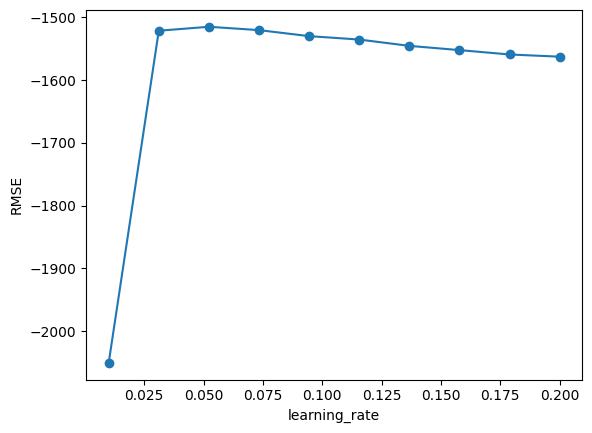

In [64]:
# Gráfica del desempeño del modelo vs la tasa en learning_rate 
plt.plot(lr_range, MSE_Score_LR, marker='o')
plt.xlabel('learning_rate')
plt.ylabel('RMSE')
plt.show()

In [65]:
print('minimo RMSE',max(MSE_Score_LR))
print('learning_rate',lr_range[np.argmax(MSE_Score_LR)])

minimo RMSE -1515.1213623046874
learning_rate 0.052222222222222225


En este caso, se evidencia que el parametro *learning_rate* el cual define que tan rapido aprende el modelo logra un pico en el valor 0.05, donde logra valores de error mas bajos.

Calibracion **gamma**

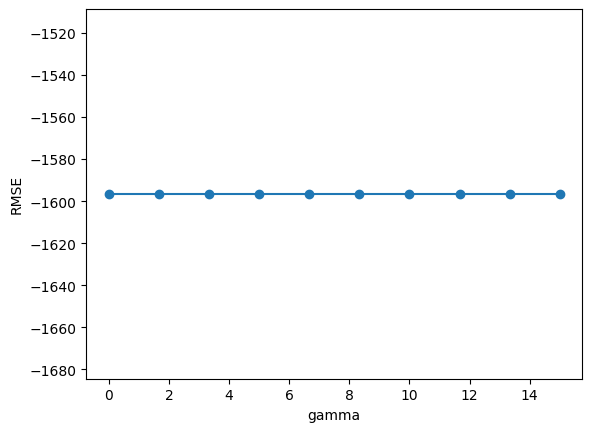

In [66]:
gm_range = np.linspace(0, 15, 10)
MSE_Score_GM = []

for gm in gm_range:
    mxgb = XGBRegressor(n_estimators=100, gamma=gm, random_state=1, n_jobs=-1)
    MSE_Score_GM.append(cross_val_score(mxgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

# Gráfica del desempeño del modelo vs parametro gamma
plt.plot(gm_range, MSE_Score_GM, marker='o')
plt.xlabel('gamma')
plt.ylabel('RMSE')
plt.show()

In [67]:
print('minimo RMSE',max(MSE_Score_GM))
print('Gamma',gm_range[np.argmax(MSE_Score_GM)])

minimo RMSE -1596.575390625
Gamma 0.0


El parametro Gamma, que decide cuando se debe dividir cada nodo. No tuvo efecto en la disminucion del error. Es decir que ninguna division queda por debajo de cada umbral definido para Gamma. Nos puede indicar un modelo balanceado

Calibracion **colsample_bytree**

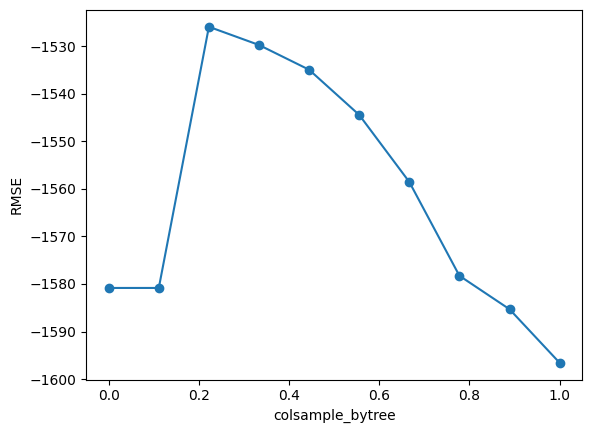

In [68]:
cb_range = np.linspace(0, 1, 10)
MSE_Score_CSBT = []

for cb in cb_range:
    mxgb = XGBRegressor(n_estimators=100, colsample_bytree=cb, random_state=1, n_jobs=-1)
    MSE_Score_CSBT.append(cross_val_score(mxgb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean())

# Gráfica del desempeño del modelo vs parametro gamma
plt.plot(cb_range, MSE_Score_CSBT, marker='o')
plt.xlabel('colsample_bytree')
plt.ylabel('RMSE')
plt.show()

In [69]:
print('minimo RMSE',max(MSE_Score_CSBT))
print('colsample_bytree',cb_range[np.argmax(MSE_Score_CSBT)])

minimo RMSE -1525.9075439453125
colsample_bytree 0.2222222222222222


El parametro *colsample_bytree* indica el porcentaje de variables usadas por el modelo, en este caso, con un 20% de variables usadas por arbol se logra una reduccion de error considerable. 

**Ejecucion del modelo con los mejores Parametros**

In [71]:
mxgb_ = XGBRegressor(n_estimators=100, learning_rate = 0.05, gamma=0 , colsample_bytree=0.2, random_state=1, n_jobs=-1)
mxgb_.fit(X_train, y_train)
y_pred = mxgb_.predict(X_test)
rmse_xgb_calibrado_colsample = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE XGBoost:", rmse_xgb_calibrado_colsample)
print("Error Relativo:", rmse_xgb_calibrado_colsample/np.mean(y_test))

RMSE XGBoost: 1987.7560841310485
Error Relativo: 0.1361479919632267


In [72]:
# sin colsample_bytree
mxgb_ = XGBRegressor(n_estimators=100, learning_rate = 0.05, gamma=0 , random_state=1, n_jobs=-1)
mxgb_.fit(X_train, y_train)
y_pred = mxgb_.predict(X_test)
rmse_xgb_calibrado_no_colsample = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE XGBoost:", rmse_xgb_calibrado_no_colsample)
print("Error Relativo:", rmse_xgb_calibrado_no_colsample/np.mean(y_test))

RMSE XGBoost: 1553.8061333383905
Error Relativo: 0.10642532383275083


#### OBSERVACIONES XGBOOST

Los resultados nos muestran que el uso de estos parametros especificos en conjunto no logran un impacto significativo en el rendimiento del modelo, para efectos de prueba se hace una segunda evaluacion omitiendo el parametro colsample_bytree, ya que consideramos que el numero de variables es pequeño para filtrarlo previamente. Con esto se obtiene metricas superiores a los modelos previos.

En conclusion, consideramos que existen parametros de mayor importancia, como max_depth y n_estimators que si permitirian un modelo mas robusto que el generado por defecto.

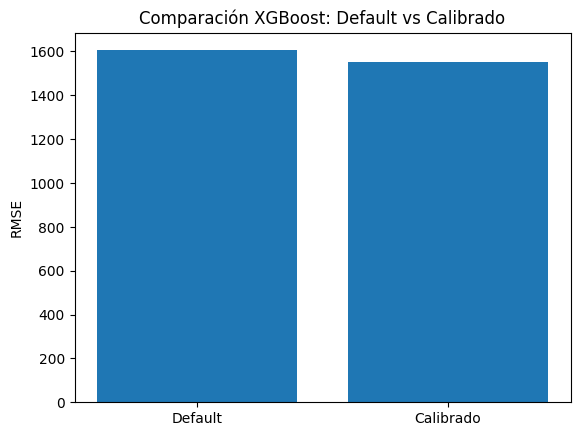

In [80]:
models = ['Default', 'Calibrado']
rmse_values = [rmse_xgb_no_calibrado, rmse_xgb_calibrado_no_colsample]

plt.bar(models, rmse_values)
plt.ylabel('RMSE')
plt.title('Comparación XGBoost: Default vs Calibrado')
plt.show()

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

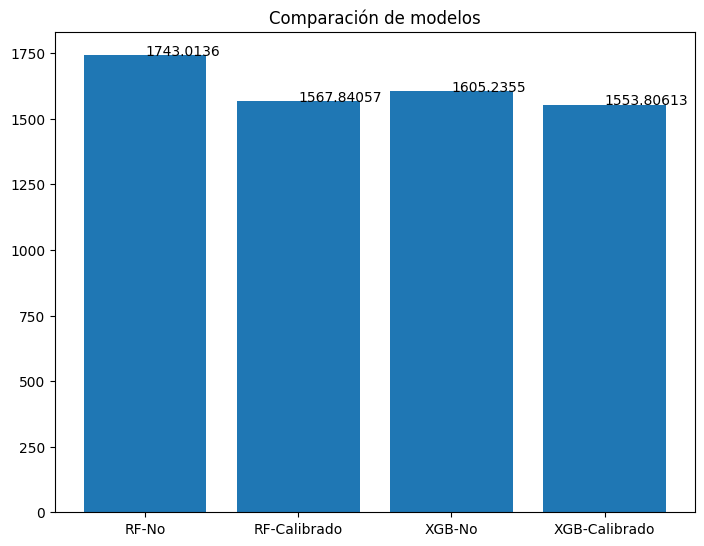

In [81]:
# Celda 8
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de modelos")
ejeX = ['RF-No', 'RF-Calibrado', 'XGB-No', 'XGB-Calibrado']
ejeY = [round(rmse_rf_no_calibrado,5),round(rmse_rf_calibrado,5),round(rmse_xgb_no_calibrado,5), round(rmse_xgb_calibrado_no_colsample,5)]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],y[i])
addlabels(ejeX,ejeY,plt)
plt.show()

RF-No = Random Forest no calibrado, 
RF-Calibrado = Random Forest Calibrado, 
XGB-No = XGBoost No calibrado, 
XGB-Calibrado = XGBoost calibrado, 

Se  compara la métrica RMSE en los modelos comentados anteriormente

En resumen podemos ver:
- El modelo con el peor desempeño y tiene el RMSE mas alto es el random forest sin calibrar con un resultado de: 1743.0136 lo que indica menor precisión en la predicción
- El modelo con el mejor desempeño y tiene el RMSE mas bajo es el XGBoost que está calibrado con un resultado de: 1553.80613 lo que indica mayor precisión en la predicción.
- Las desventajas de random forest sin calibrar no alcanza su mejor rendimiento y tiene una precisión menor, al no estar optimizado y no tener la calibración de hiperparámetros su desempeño que limita su capacidad a compración del Random Forest calibrado que tiene un RMSE de: 1567.84057 que incluso está muy cercano al valor de XGBoost calibrado, el cual, tuvo el mejor desempeño.
- Random Forest sin equilibrar puede no lograr aprovechar al máximo el dataset, no está optimizado para trabajar con la data que tenía para la predicción y por ende tener un rango salarial, RMSE de USD mayor a los demás modelos.
- Las ventajas de XGBoost calibrado aquí podemos ver que hay un RMSE de: USD 1553.80613 que es menor a los demás modelos y captura mejor las relaciones con los datos indicando que tiene predicciones mas precisas, entonces está logrando trabajar bien con la variación de los precios.
- XGBoost al no ser calibrado aún así sigue teniendo un RMSE bajo, siendo esta buen modelo para realizar predicciones mas precisas aunque su interpretación sea mas complejo en comparación a modelos simples.